## AdaGrad

简介：对每个参数进行单独的学习率调整，适应于稀疏特征和频繁更新的特征。

$$
\begin{split}
\theta_{t+1,i}&=\theta_{t,i} - \frac{\eta}{\sqrt{G_{t,ii}+\epsilon}}\cdot g_{t,i\cdot}\\
G&=\sum_{\tau=1}^tg_\tau g_\tau^T
\end{split}
$$

- sparse feature and learning rate

    - sparse or dense: BoW (Bag of Words)，偶尔为1（或者说出现）
        - 只有在这些不常见的特征出现时，相关的参数才会得到有意义的更新；
    - 常见特征的参数相当迅速地收敛到最佳值，而对于不常见的特征，我们仍缺乏足够的观测以确定其最佳值。 
    - 换句话说，学习率要么对于常见特征而言降低太慢，要么对于不常见特征而言降低太快。
    - leanring rate 的降低
        - $\mathcal{O}(t^{-\frac{1}{2}}): \eta = \frac{\eta_0}{\sqrt{t + c}}$
        - $\eta_{i,t} = \frac{\eta_0}{\sqrt{s(i, t) + c}}$
- $i$ 表示 parameter（$\theta$） 的 index；
- $G$ 是历史梯度信息的平方；
    - $G$ 是一个方阵，对角 $G_{,ii}$ 表示 $\sum_{t}g_{t,i}^2$
    - running sum
- $G_{t,ii}$
    - 作为 $\eta$ 的 scaling factor；
- Adagrad is an optimizer with parameter-specific learning rates, which are adapted relative to how frequently a parameter gets updated during training. 
   
    - The more updates a parameter receives, the smaller the learning rate.
    - 每个坐标轴（axis/dimension/coordinate）都有自己的学习率，

$$
\begin{split}
    \begin{aligned}
        \mathbf{g}_t & = \partial_{\mathbf{w}} l(y_t, f(\mathbf{x}_t, \mathbf{w})), \\
        \mathbf{s}_t & = \mathbf{s}_{t-1} + \mathbf{g}_t^2, \quad \mathbf{s}_0 = \mathbf{0}\\
        \mathbf{w}_t & = \mathbf{w}_{t-1} - \frac{\eta}{\sqrt{\mathbf{s}_t + \epsilon}} \odot \mathbf{g}_t.
    \end{aligned}
\end{split}
$$

- $\cdot$ 表示 dot product（内积），会把对应元素相乘后再求和，结果是一个标量
- $\odot$ 表示 element-wise product（逐元素乘积）
- 逐元素乘积 $\frac{\eta}{\sqrt{\mathbf{s}_t + \epsilon}} \odot \mathbf{g}_t$ 表示每个参数的更新量是根据其历史梯度的平方和分别进行调整的。

$$
f(x)=0.1x_1^2 + 2x_2^2
$$

In [1]:
import math
import torch

In [2]:
def f(x):
    return 0.1 * x[0] ** 2 + 2 * x[1] ** 2

In [3]:
def f_grad(x):
    return 0.2*x[0], 4*x[1]

In [4]:
def adagrad_step(x, s, f_grad, eta=1e-2, eps=1e-6):
    g = f_grad(x)
    s[0] += g[0]**2
    s[1] += g[1]**2
    x[0] -= eta / math.sqrt(s[0] + eps) * g[0]
    x[1] -= eta / math.sqrt(s[1] + eps) * g[1]
#     x[0] -= eta * g[0]
#     x[1] -= eta * g[1]
    return x, s

In [5]:
def train(step_fn, x0, s0, f_grad, steps=20, eta=1e-2):
    traces = [x0.copy()]
    x = x0
    s = s0
    for i in range(steps):
        x, s = step_fn(x, s, f_grad, eta)
        traces.append(x.copy())
    return traces

[-2.382562771979649, -0.15859055003666966]


Text(0, 0.5, 'x2')

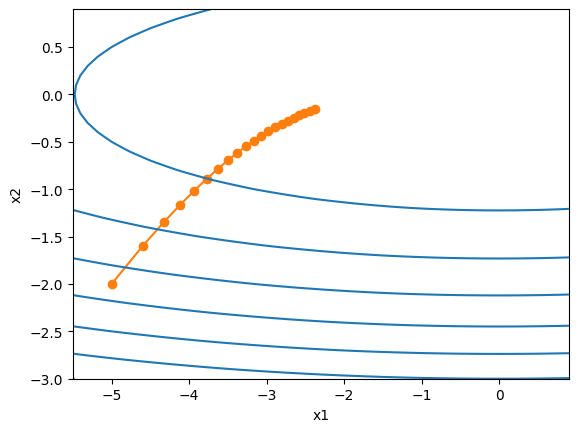

In [6]:
x0 = [-5, -2]
s0 = [0, 0]
traces = train(adagrad_step, x0, s0, f_grad, eta=.4)
print(traces[-1])
# traces

import matplotlib.pyplot as plt  # noqa: E402
plt.plot(*zip(*traces), '-o', color='#ff7f0e')
x1, x2 = torch.meshgrid(torch.arange(-5.5, 1., .1), 
               torch.arange(-3, 1., .1), indexing='ij')
plt.contour(x1, x2, f([x1, x2]), colors='#1f77b4')
plt.xlabel('x1')
plt.ylabel('x2')

[-0.002295340252192116, -1.4349291647375306e-162]


Text(0, 0.5, 'x2')

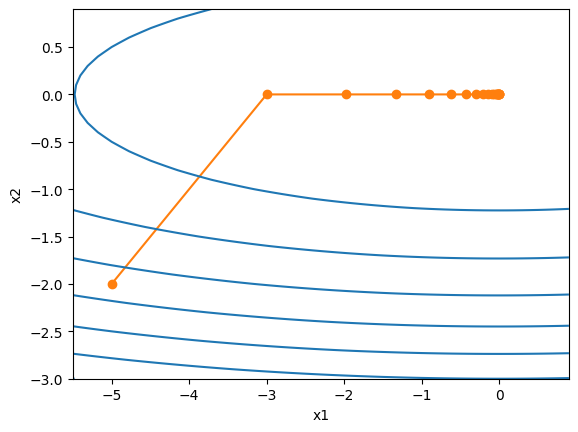

In [ ]:
x0 = [-5, -2]
s0 = [0, 0]
traces = train(adagrad_step, x0, s0, f_grad, eta=2)
print(traces[-1])
# traces

import matplotlib.pyplot as plt  # noqa: E402
plt.plot(*zip(*traces), '-o', color='#ff7f0e')
x1, x2 = torch.meshgrid(torch.arange(-5.5, 1., .1), 
               torch.arange(-3, 1., .1), indexing='ij')
plt.contour(x1, x2, f([x1, x2]), colors='#1f77b4')
plt.xlabel('x1')
plt.ylabel('x2')

## rmsprop

- adaptive gradient，$\eta_{i,t} = \frac{\eta_0}{\sqrt{s(i, t) + c}}, \mathcal O(t^{-\frac12})$
    - coordinate-adaptive learning rates.
    
$$
\begin{split}\begin{aligned}
    \mathbf{s}_t & \leftarrow \gamma \mathbf{s}_{t-1} + (1 - \gamma) \mathbf{g}_t^2, \\
    \mathbf{w}_t & \leftarrow \mathbf{w}_{t-1} - \frac{\eta}{\sqrt{\mathbf{s}_t + \epsilon}} \odot \mathbf{g}_t.
\end{aligned}\end{split}
$$

$$
\begin{split}
\mathbf s_t&=(1-\gamma)\mathbf g_t^2 + \gamma\mathbf s_{t-1}\\
&=(1-\gamma)\mathbf g_t^2 + \gamma \left((1-\gamma)\mathbf g_{t-1}^2+\gamma s_{t-2}\right)\\
&=(1-\gamma)(\mathbf g_t^2+\gamma \mathbf g_{t-1}^2 + \gamma^2\mathbf g_{t-2}^2+\cdots)
\end{split}
$$

In [8]:
def rmsprop_step(x, s, f_grad, eta=1e-2, gamma=0.9, eps=1e-6, ):
    g = f_grad(x)
    s[0] = gamma*s[0] + (1-gamma)*g[0]**2
    s[1] = gamma*s[1] + (1-gamma)*g[1]**2
    x[0] -= eta / math.sqrt(s[0] + eps) * g[0]
    x[1] -= eta / math.sqrt(s[1] + eps) * g[1]
    return x, s

[-0.01059867213411372, 1.0362121337275157e-14]


Text(0, 0.5, 'x2')

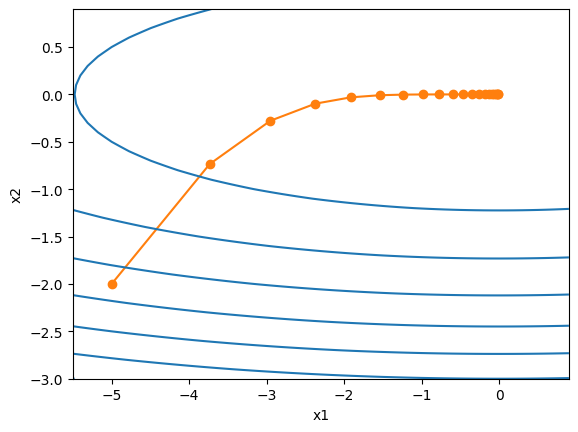

In [9]:
x0 = [-5, -2]
s0 = [0, 0]
traces = train(rmsprop_step, x0, s0, f_grad, eta=.4)
print(traces[-1])
# traces

import matplotlib.pyplot as plt  # noqa: E402
plt.plot(*zip(*traces), '-o', color='#ff7f0e')
x1, x2 = torch.meshgrid(torch.arange(-5.5, 1., .1), 
               torch.arange(-3, 1., .1), indexing='ij')
plt.contour(x1, x2, f([x1, x2]), colors='#1f77b4')
plt.xlabel('x1')
plt.ylabel('x2')